<a href="https://colab.research.google.com/github/QasimNiazi86/MLP_Classifier/blob/main/Tutorial2Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Task 1: Architecture Experiments (LR = 0.01) ---
Architecture [10]: Test Accuracy = 100.00%
Architecture [10, 10]: Test Accuracy = 100.00%
Architecture [50, 50]: Test Accuracy = 100.00%
Architecture [64, 32, 16]: Test Accuracy = 97.78%

--- Task 2: Learning Rate Experiments (Arch = [10, 10]) ---
Learning Rate 0.1: Test Accuracy = 100.00%
Learning Rate 0.01: Test Accuracy = 100.00%
Learning Rate 0.001: Test Accuracy = 97.78%
Learning Rate 0.0001: Test Accuracy = 28.89%


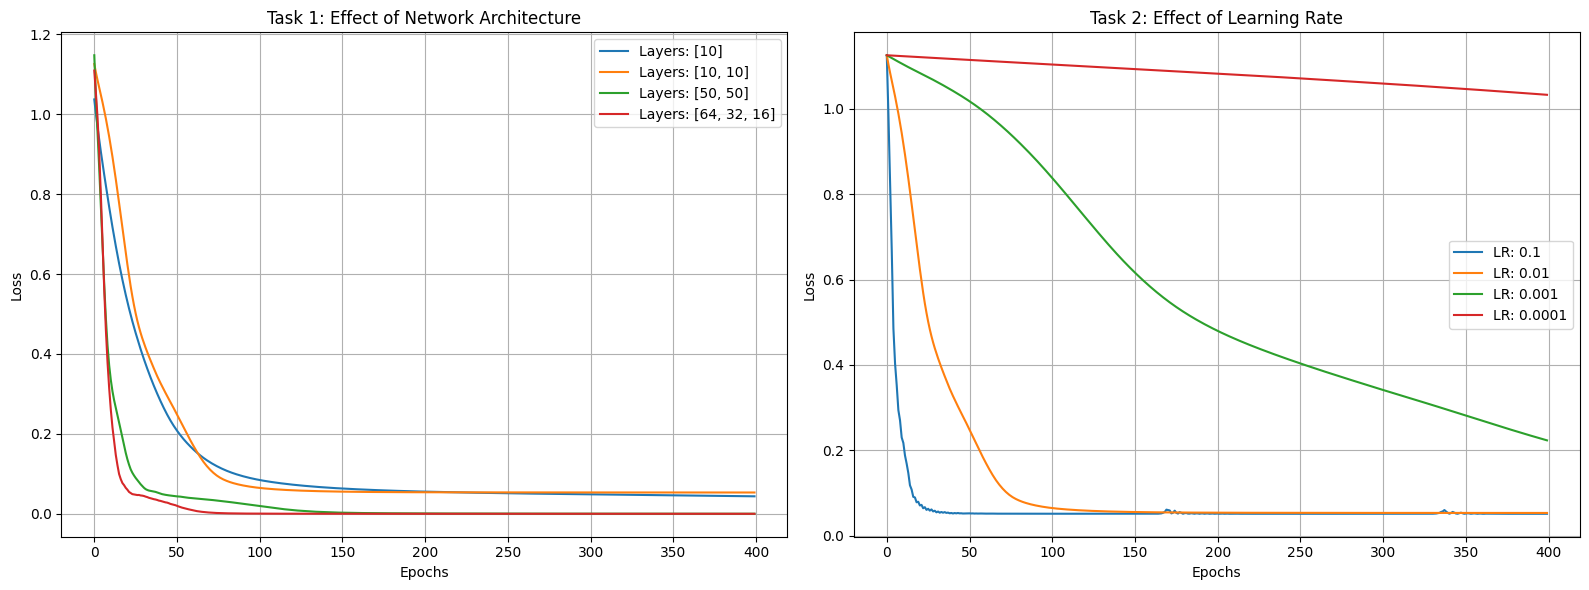

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Preparation
# ==========================================
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_t = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
X_test_t = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ==========================================
# 2. Dynamic MLP Architecture (Task 1)
# ==========================================
class FlexibleMLP(nn.Module):
    def __init__(self, input_size=4, hidden_sizes=[10, 10], num_classes=3):
        super(FlexibleMLP, self).__init__()
        layers = []
        in_features = input_size

        # Dynamically create hidden layers based on the input list
        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_features, h_size))
            layers.append(nn.ReLU())
            in_features = h_size

        # Output layer
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. Reusable Training Function
# ==========================================
def train_and_evaluate(hidden_sizes, lr, epochs=400):
    # Set seed for fair comparison
    torch.manual_seed(42)

    model = FlexibleMLP(hidden_sizes=hidden_sizes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

    # Evaluate
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        _, y_pred = torch.max(test_outputs, 1)
        accuracy = accuracy_score(y_test_t.numpy(), y_pred.numpy())

    return loss_history, accuracy

# ==========================================
# 4. Running the Experiments
# ==========================================

# --- Task 1: Experimenting with Architectures ---
# Keeping learning rate constant to isolate the effect of architecture
constant_lr = 0.01
architectures = [
    [10],               # 1 hidden layer, 10 neurons (Underpowered)
    [10, 10],           # 2 hidden layers, 10 neurons each (Baseline)
    [50, 50],           # 2 hidden layers, 50 neurons each (Wider)
    [64, 32, 16]        # 3 hidden layers, decreasing neurons (Deeper)
]

print("--- Task 1: Architecture Experiments (LR = 0.01) ---")
arch_results = {}
for arch in architectures:
    losses, acc = train_and_evaluate(hidden_sizes=arch, lr=constant_lr)
    arch_results[str(arch)] = losses
    print(f"Architecture {arch}: Test Accuracy = {acc*100:.2f}%")

# --- Task 2: Experimenting with Learning Rates ---
# Keeping architecture constant to isolate the effect of learning rate
constant_arch = [10, 10]
learning_rates = [0.1, 0.01, 0.001, 0.0001]

print("\n--- Task 2: Learning Rate Experiments (Arch = [10, 10]) ---")
lr_results = {}
for lr in learning_rates:
    losses, acc = train_and_evaluate(hidden_sizes=constant_arch, lr=lr)
    lr_results[str(lr)] = losses
    print(f"Learning Rate {lr}: Test Accuracy = {acc*100:.2f}%")

# ==========================================
# 5. Plotting the Results
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot Architecture Results
for arch_str, losses in arch_results.items():
    ax1.plot(losses, label=f'Layers: {arch_str}')
ax1.set_title('Task 1: Effect of Network Architecture')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Learning Rate Results
for lr_str, losses in lr_results.items():
    ax2.plot(losses, label=f'LR: {lr_str}')
ax2.set_title('Task 2: Effect of Learning Rate')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()